In [5]:
import yfinance as yf
import numpy as np
import sys
print(sys.executable)
import sys
!{sys.executable} -m pip install yfinance
from src.risk.monte_carlo_var import monte_carlo_option_var
ticker_symbol = "AAPL"
ticker = yf.Ticker(ticker_symbol)

# 1. Get latest stock price
stock_hist = ticker.history(period="5d") #check the timeline as well.
S0 = stock_hist["Close"].iloc[-1]

# 2. Get nearest option expiration
exp = ticker.options[0]
chain = ticker.option_chain(exp)

calls = chain.calls
puts = chain.puts

# 3. Pick one option contract
option = calls.iloc[0]

K = option["strike"]

#check these ones. 
option_price = option["lastPrice"]
implied_vol = option["impliedVolatility"]

print("Stock price S0:", S0)
print("Strike K:", K)
print("Option price:", option_price)
print("Implied volatility:", implied_vol)
print("Expiration:", exp)

contracts = 10
portfolio_value = option_price * 100 * contracts
print("Current Option Portfolio Value:", portfolio_value)

/Users/sangpark/Documents/Risk class project/risk-system-main/.venv/bin/python
zsh:1: no such file or directory: /Users/sangpark/Documents/Risk
Stock price S0: 293.32000732421875
Strike K: 230.0
Option price: 46.0
Implied volatility: 3.1845723510742188
Expiration: 2026-05-11
Current Option Portfolio Value: 46000.0


In [7]:
option = calls.iloc[0]
K = option["strike"]
option_price = option["lastPrice"]
sigma = option["impliedVolatility"]
result = monte_carlo_option_var(
    S0=S0,
    K=K,
    T=0.5,
    r=0.05,
    sigma=sigma,
    option_price=option_price,
    option_type="call",
    contracts=contracts,
    n_sim=50000,
    confidence=0.99,
    horizon_days=10
)
print("Monte Carlo Option VaR:", result["var"])

Monte Carlo Option VaR: 18820.7186050494


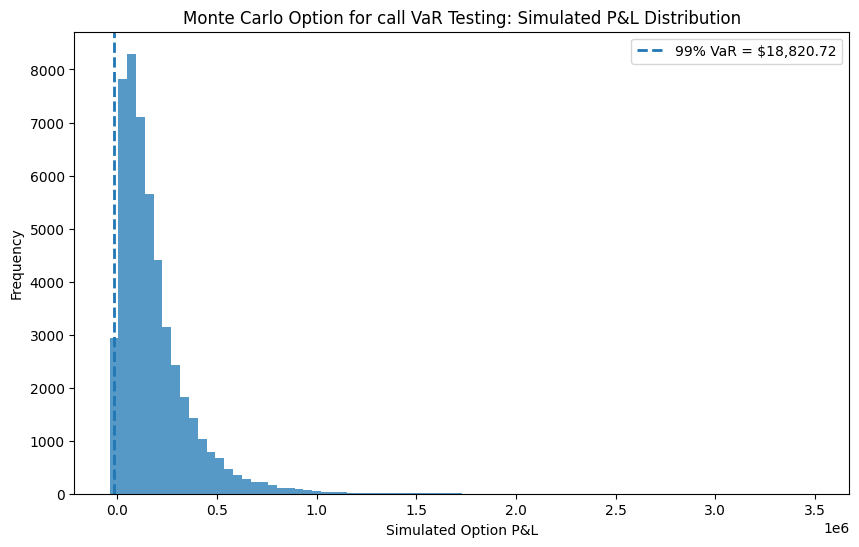

In [ ]:
import matplotlib.pyplot as plt
pnl = result["pnl"]
var = result["var"]

plt.figure(figsize=(10, 6))
plt.hist(pnl, bins=80, alpha=0.75)

# VaR line
plt.axvline(-var, linestyle="--", linewidth=2, label=f"99% VaR = ${var:,.2f}")
plt.title("Monte Carlo Option for call VaR Testing: Simulated P&L Distribution")
plt.xlabel("Simulated Option P&L")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [2]:
import sys
print(sys.executable)

/Users/sangpark/Documents/Risk class project/risk-system-main/.venv/bin/python


Put option

In [ ]:
import pandas as pd
import numpy as np

# Select ATM put
closest_idx = (puts["strike"] - S0).abs().idxmin()
option = puts.loc[closest_idx]

K = option["strike"]
option_price = option["lastPrice"]
sigma = option["impliedVolatility"]

# Correct time to maturity
expiration_date = pd.to_datetime(exp).tz_localize(None)
today = stock_hist.index[-1].tz_localize(None)

T = max((expiration_date - today).days / 365, 1 / 365)

# Horizon cannot exceed remaining maturity
horizon_days = min(1, max((expiration_date - today).days, 1))
result = monte_carlo_option_var(
    S0=S0,
    K=K,
    T=T,
    r=0.05,
    sigma=sigma,
    option_price=option_price,
    option_type="put",
    contracts=contracts,
    n_sim=50000,
    confidence=0.99,
    horizon_days=horizon_days
)
raw_var = result["var"]
clean_var = max(raw_var, 0)

print("Selected Put:")
print(option)

print("T:", T)
print("Horizon days:", horizon_days)
print("Monte Carlo Put VaR:", clean_var)
print("1% PnL percentile:", np.percentile(result["pnl"], 1))

Selected Put:
contractSymbol             AAPL260511P00292500
lastTradeDate        2026-05-08 19:59:57+00:00
strike                                   292.5
lastPrice                                 1.54
bid                                       1.45
ask                                        1.6
change                                   -4.89
percentChange                        -76.04977
volume                                  7218.0
openInterest                               425
impliedVolatility                     0.319831
inTheMoney                               False
contractSize                           REGULAR
currency                                   USD
Name: 29, dtype: object
T: 0.00821917808219178
Horizon days: 1
Monte Carlo Put VaR: 1522.2154169396852
1% PnL percentile: -1522.2154169396852
